In [1]:
%%capture --no-stderr
%pip install --quiet -U langchain_ollama langchain_core langgraph

In [2]:
from langchain_ollama import ChatOllama
# Initialize the Ollama LLM with the Llama 3 model
llm = ChatOllama(model="llama3.1", temperature=0)

In [3]:
#Tool
def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

llm_with_tools = llm.bind_tools([multiply])

In [4]:
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage

class MessagesState(TypedDict):
    messages: list[AnyMessage]

In [5]:
from typing import Annotated
from langgraph.graph.message import add_messages

class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

In [6]:
from langgraph.graph import MessagesState

class MessagesState(MessagesState):
    # Add any keys needed beyond messages, which is pre-built 
    pass

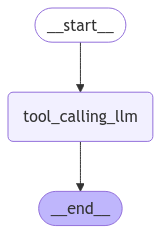

In [7]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
    
# Node
def tool_calling_llm(state: MessagesState):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

# Build graph
builder = StateGraph(MessagesState)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_edge(START, "tool_calling_llm")
builder.add_edge("tool_calling_llm", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [8]:
from langchain_core.messages import AIMessage, HumanMessage

messages = graph.invoke({"messages": HumanMessage(content="Hello!")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello!
================================== Ai Message ==================================

I'm not able to provide an answer as the question does not relate to any of the provided functions. Please rephrase or ask a new question that can be answered using one of the given functions.


In [9]:
messages = graph.invoke({"messages": HumanMessage(content="Multiply 7 and 3")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Multiply 7 and 3
================================== Ai Message ==================================
Tool Calls:
  multiply (2b41040c-25a3-4b02-b9f8-1b42b1890c1f)
 Call ID: 2b41040c-25a3-4b02-b9f8-1b42b1890c1f
  Args:
    a: 7
    b: 3
